# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
df = pd.read_csv('loan_data.csv')
df.head()

df.head(25)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1
5,22,male,Bachelor,70130.700025,6,MORTGAGE,9008.104188,VENTURE,12.575501,0.128447,22,770.974257,No,0
6,41,female,Associate,86965.993882,11,OWN,23398.537788,EDUCATION,11.770607,0.269054,19,596.305523,No,1
7,72,female,Associate,60412.931964,6,MORTGAGE,24495.392501,PERSONAL,9.146556,0.405466,19,734.020668,No,0
8,21,male,Bachelor,77241.160427,25,RENT,17674.382881,DEBTCONSOLIDATION,14.211276,0.228821,22,653.042056,No,0
9,49,male,Doctorate,57373.429325,4,OWN,14848.496412,PERSONAL,12.188035,0.258804,26,738.978230,No,1


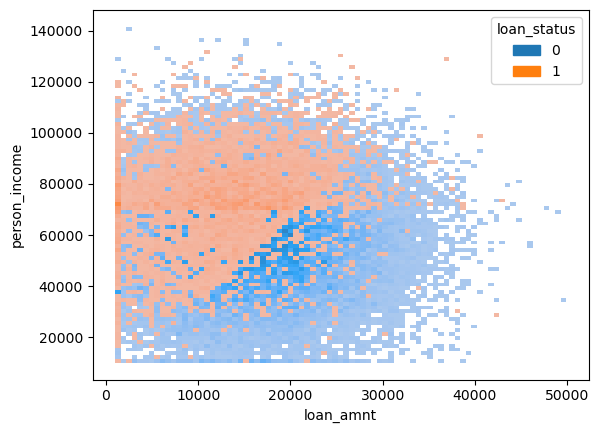

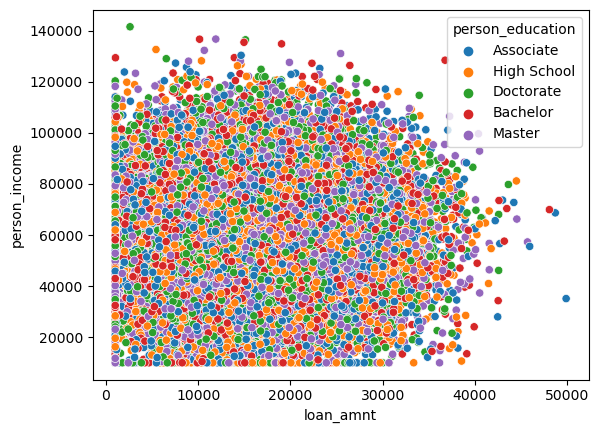

In [9]:
sns.histplot(
        data=df,
        x = 'loan_amnt',
        y = 'person_income',
        hue = 'loan_status',
        element="step",
        kde=True,

)
plt.show()

sns.scatterplot(
        data=df,
        x = 'loan_amnt',
        y = 'person_income',
        hue = 'person_education',
           
)
plt.show()

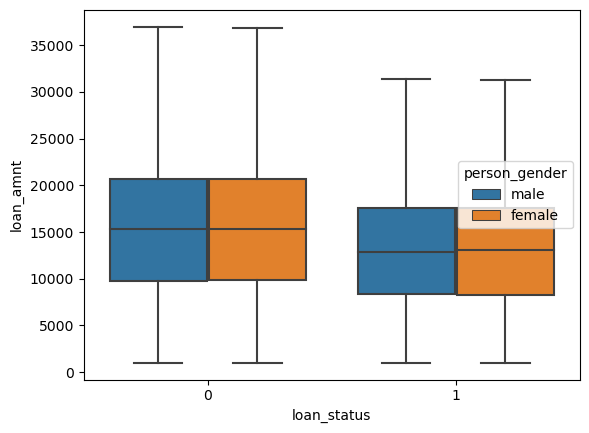

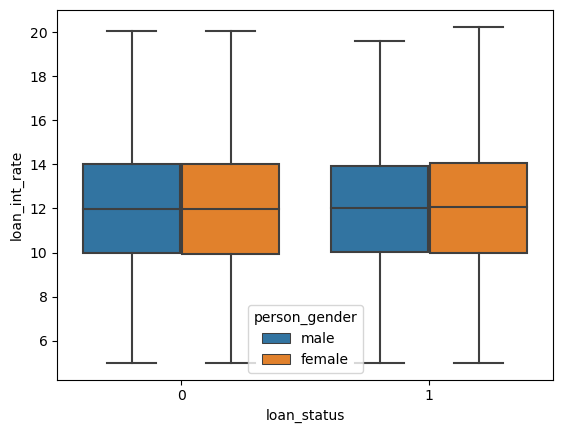

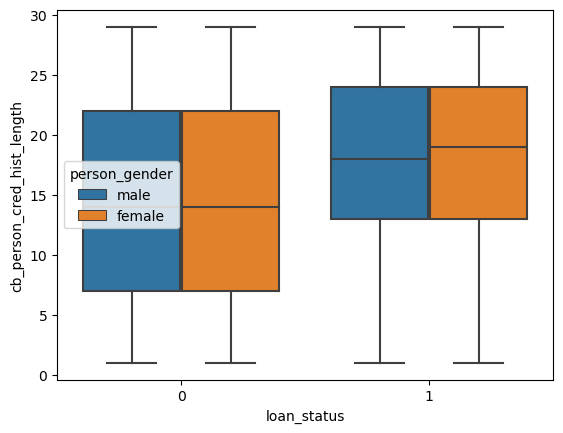

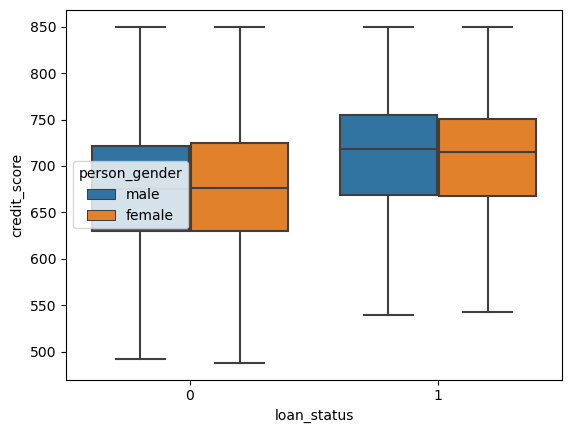

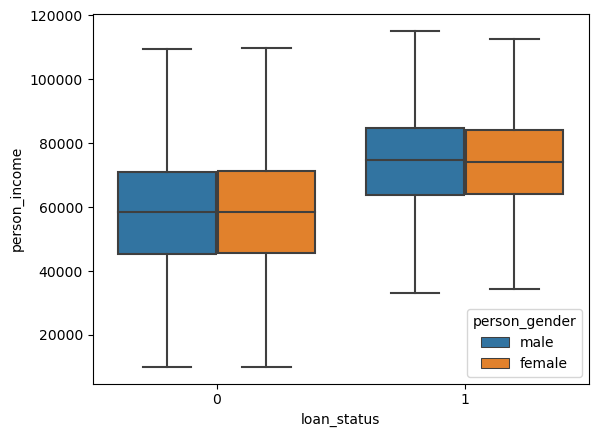

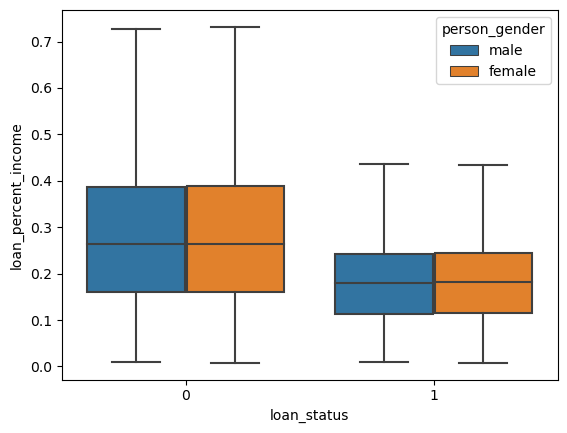

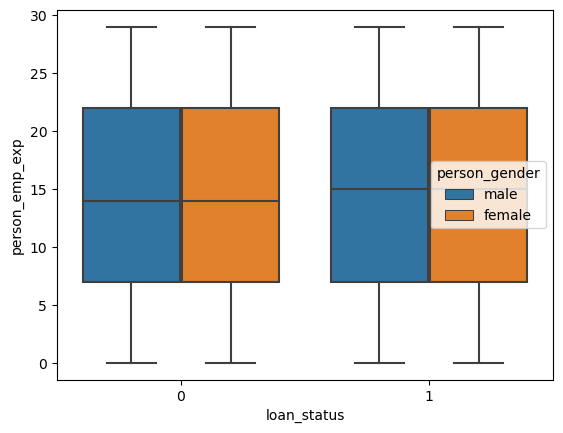

In [12]:
features = [
    "loan_amnt",
    "loan_int_rate",
    "cb_person_cred_hist_length",
    "credit_score",
    "person_income",
    "loan_percent_income",
    "person_emp_exp"
]

person_factors = ['loan_intent', 'person_education', 'person_home_ownership', 'previous_loan_defaults_on_file']
for feature in features:
    sns.boxplot(
        data=df,
        x="loan_status",
        y=feature,
        hue = 'person_gender',
        showfliers=False
    )
    plt.show()



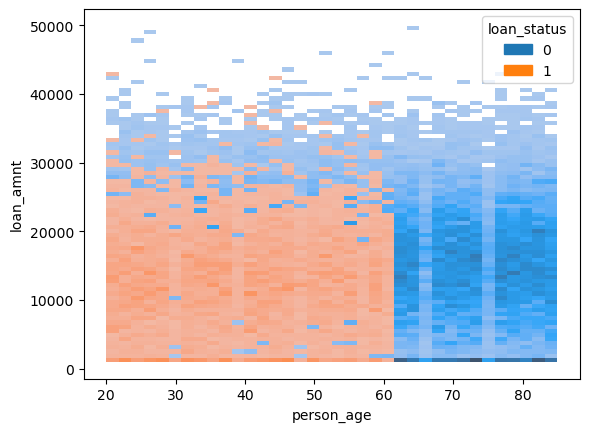

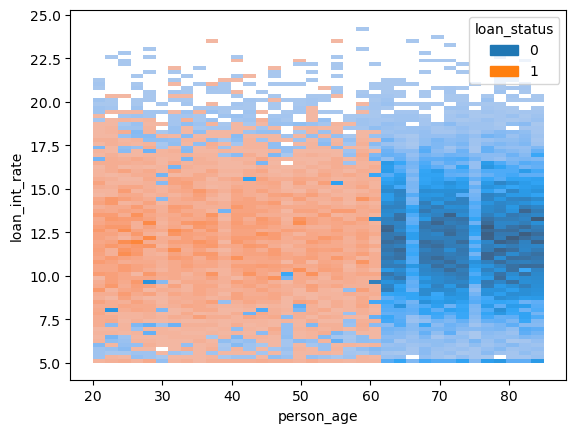

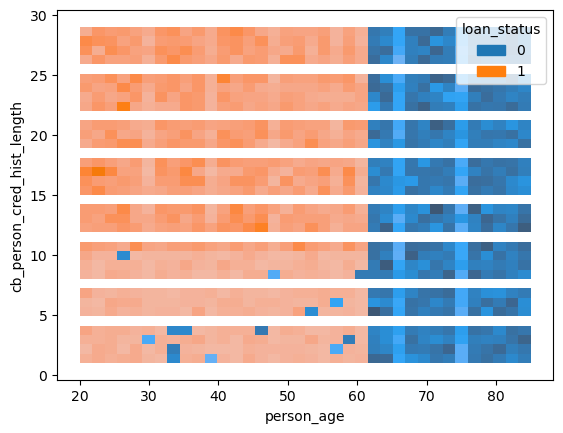

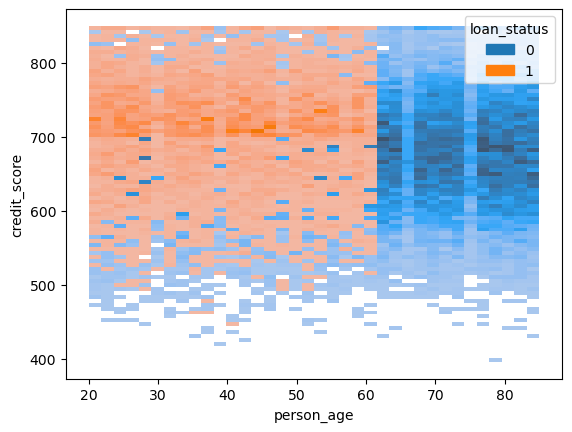

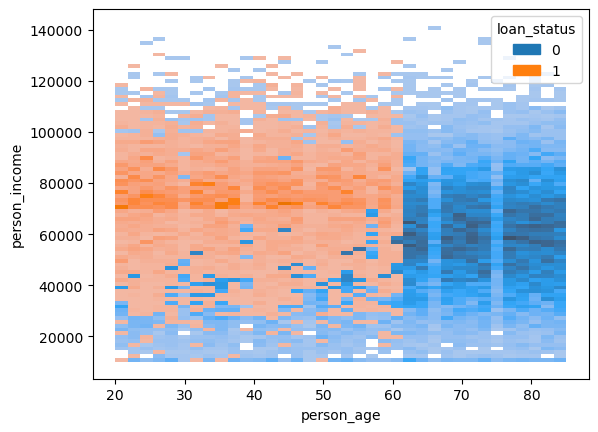

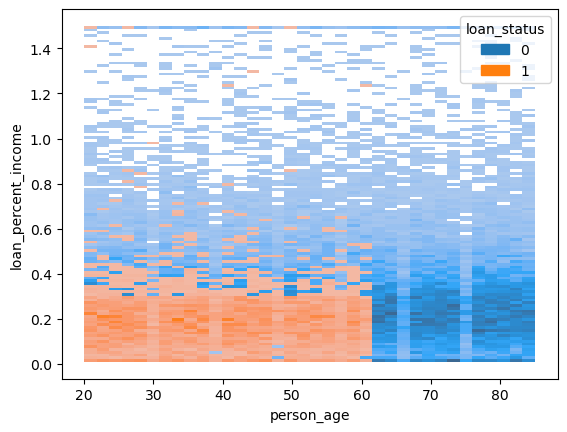

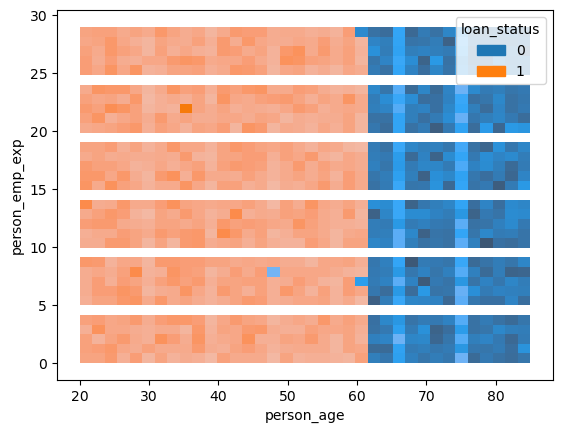

In [26]:
for feature in features:
    sns.histplot(
        data=df,
        x="person_age",
        y= feature,
        hue = 'loan_status',
        element="step",
    )
    plt.show()

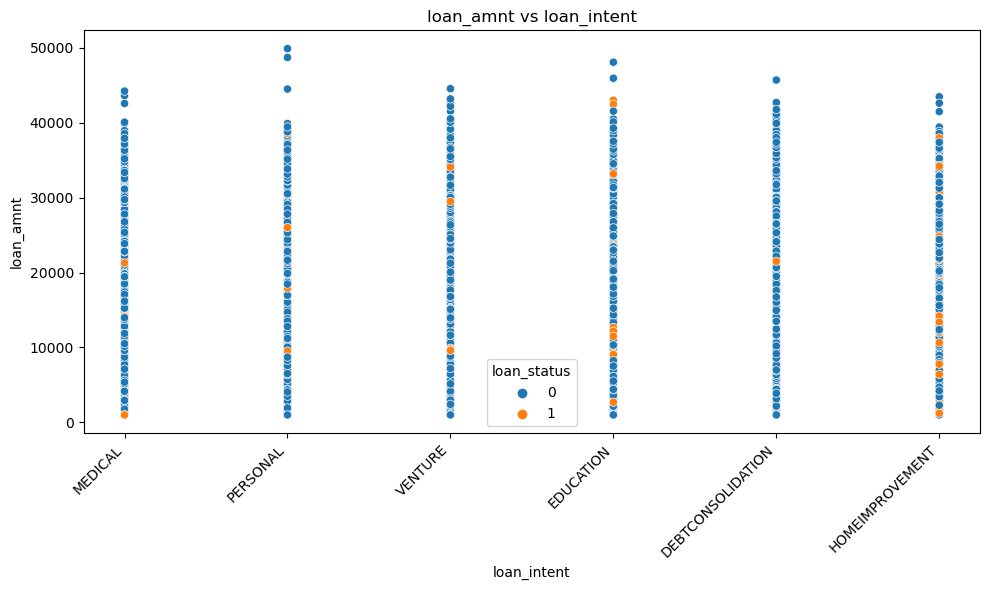

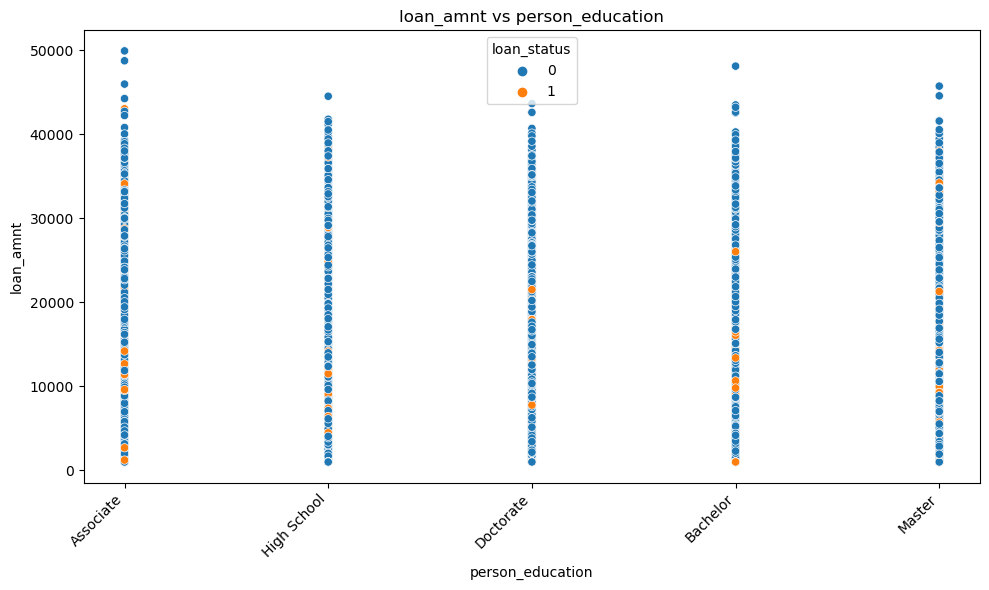

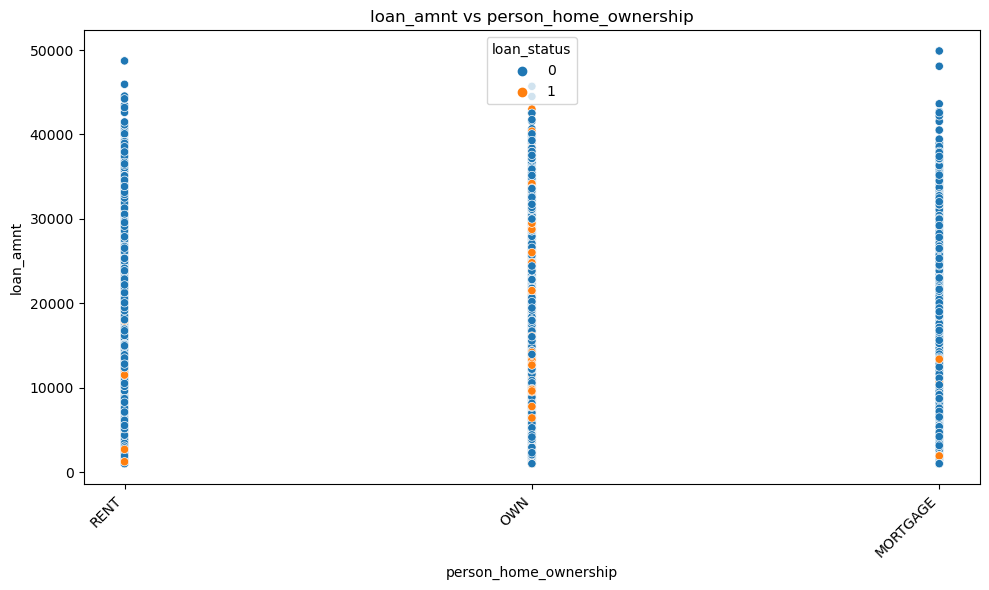

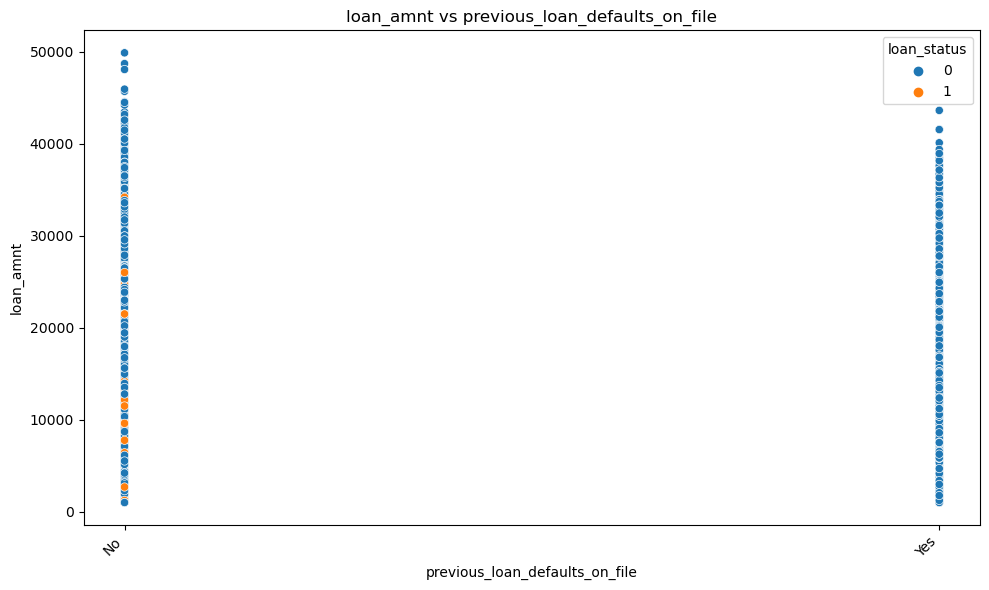

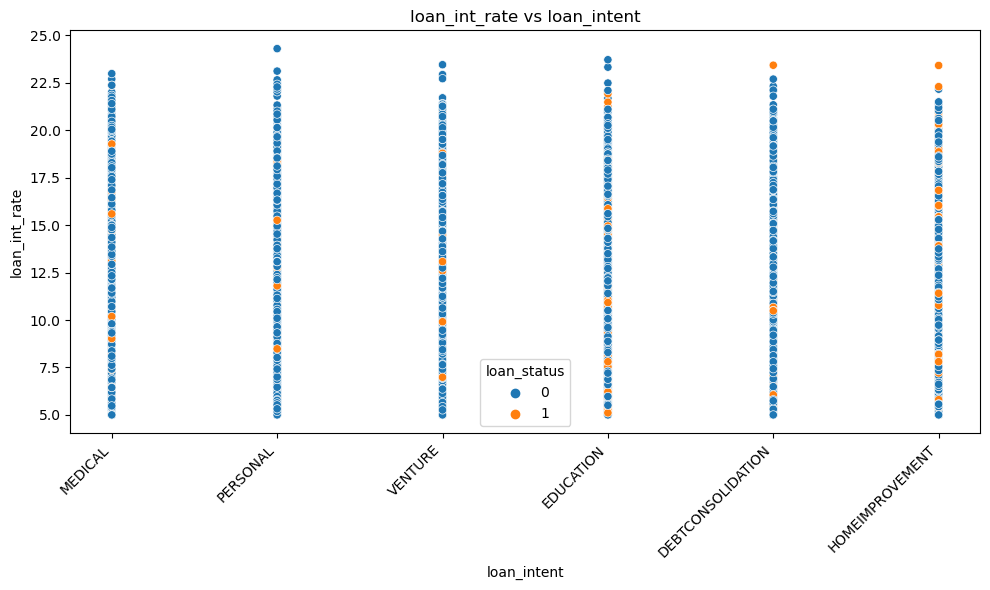

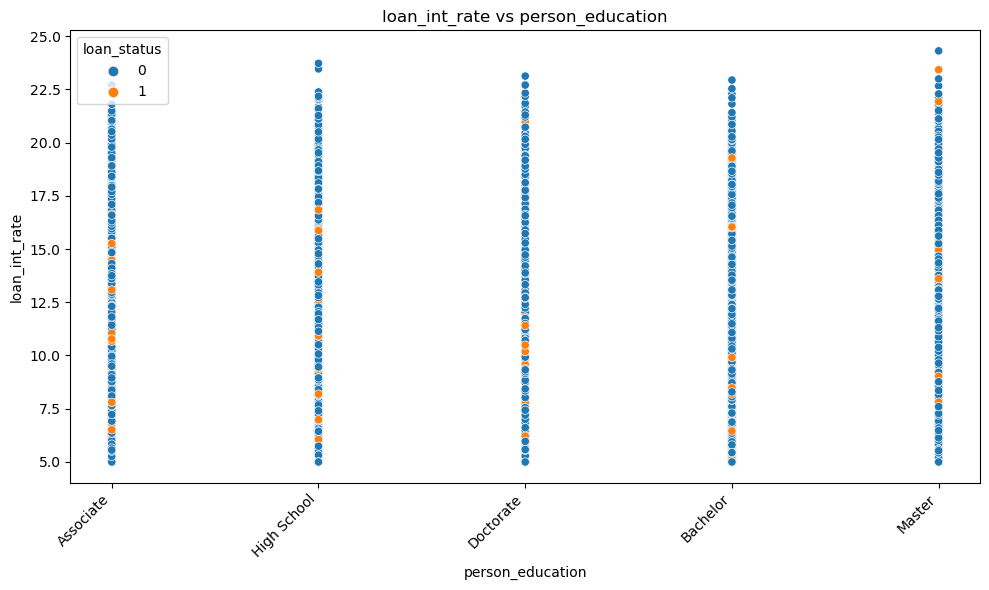

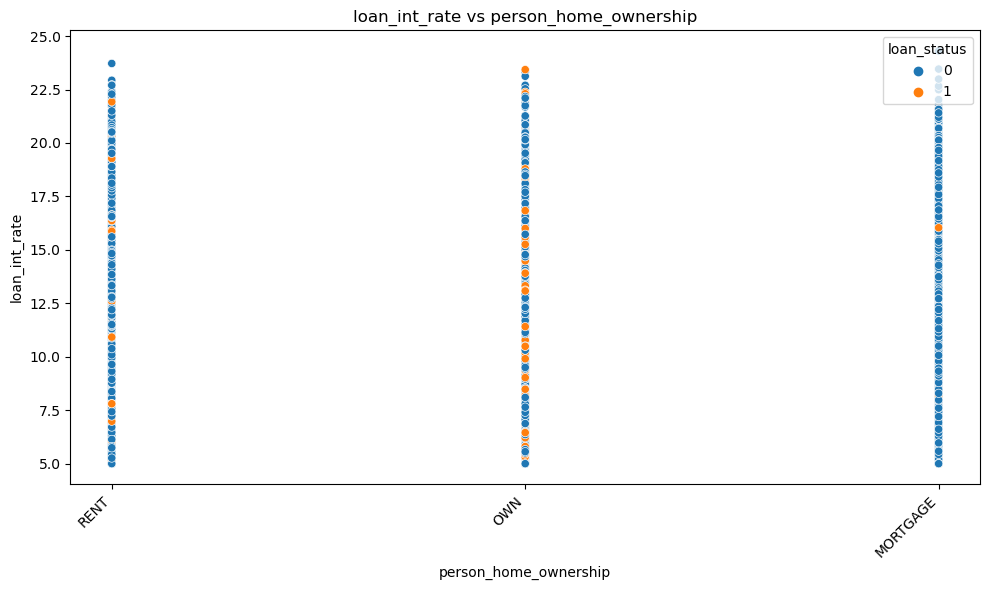

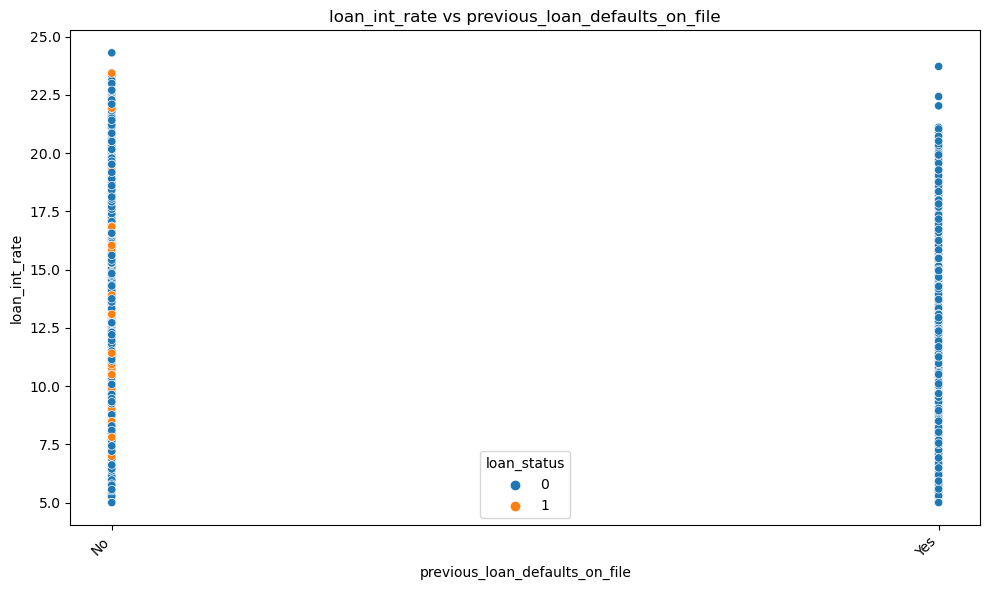

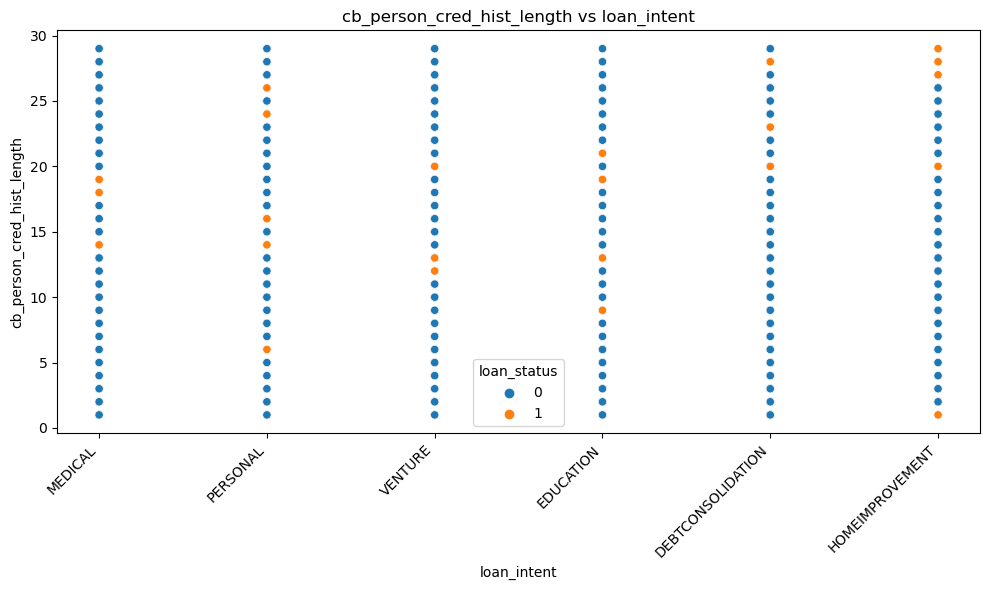

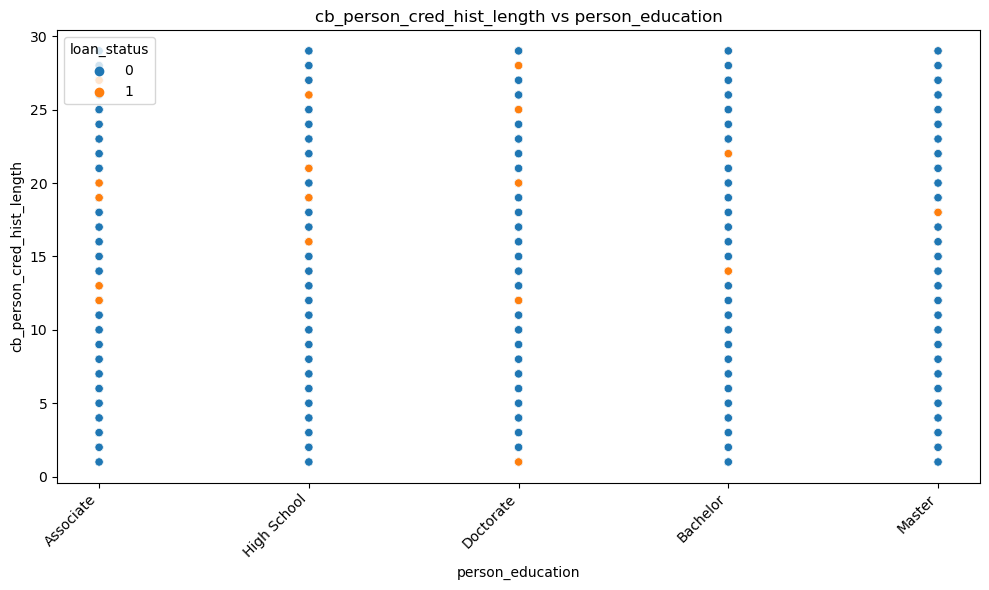

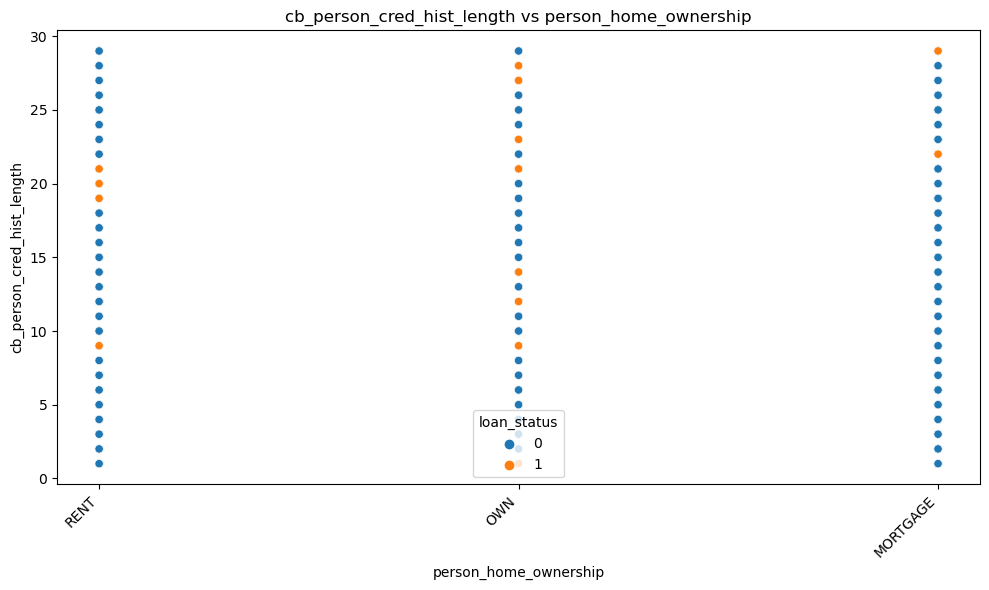

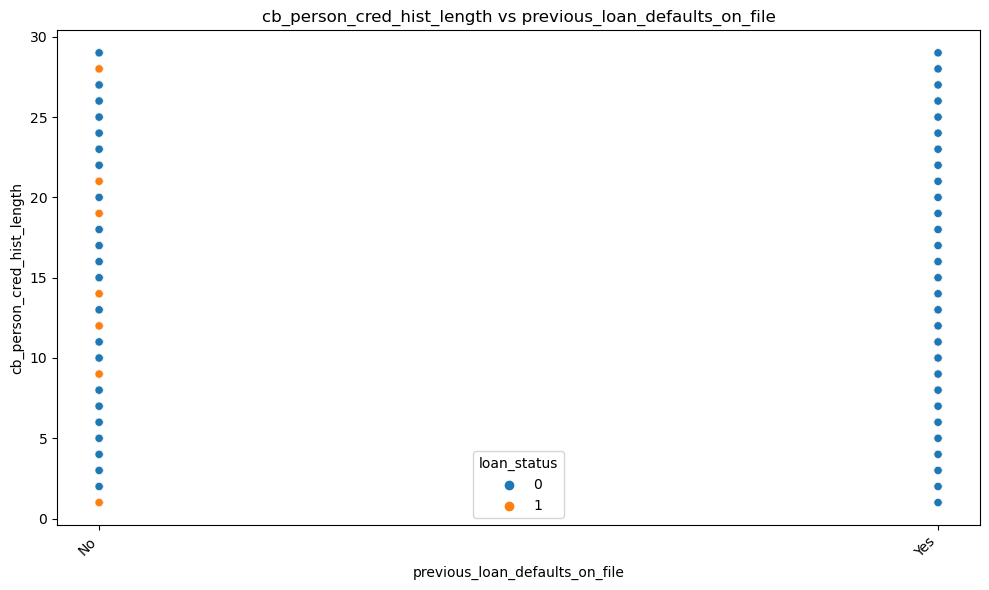

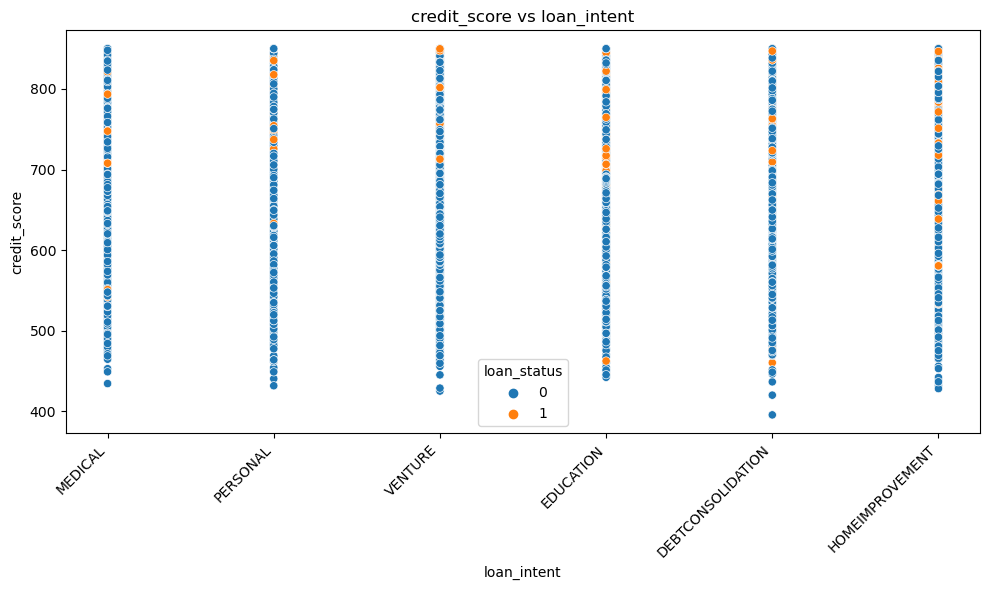

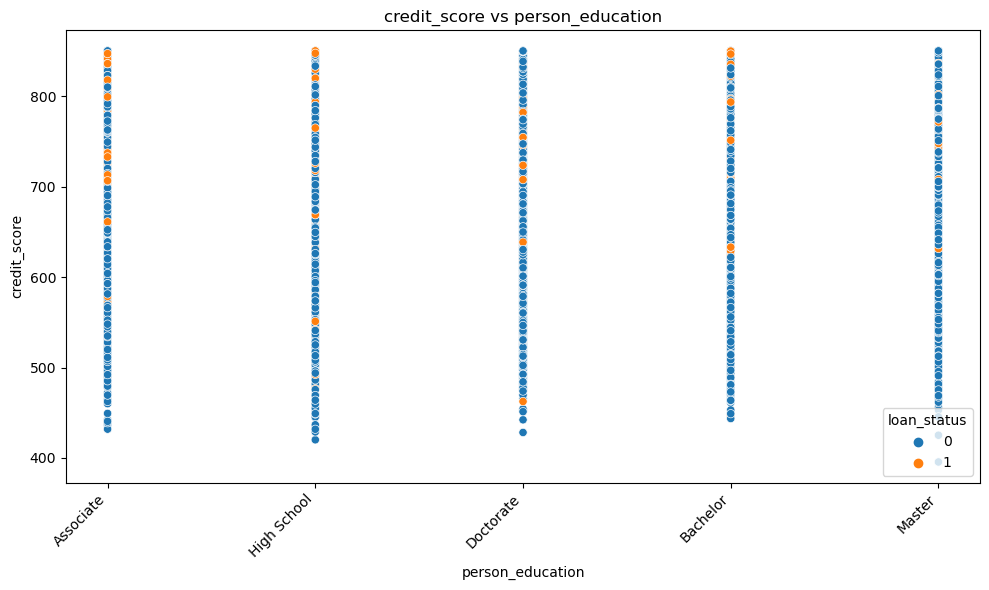

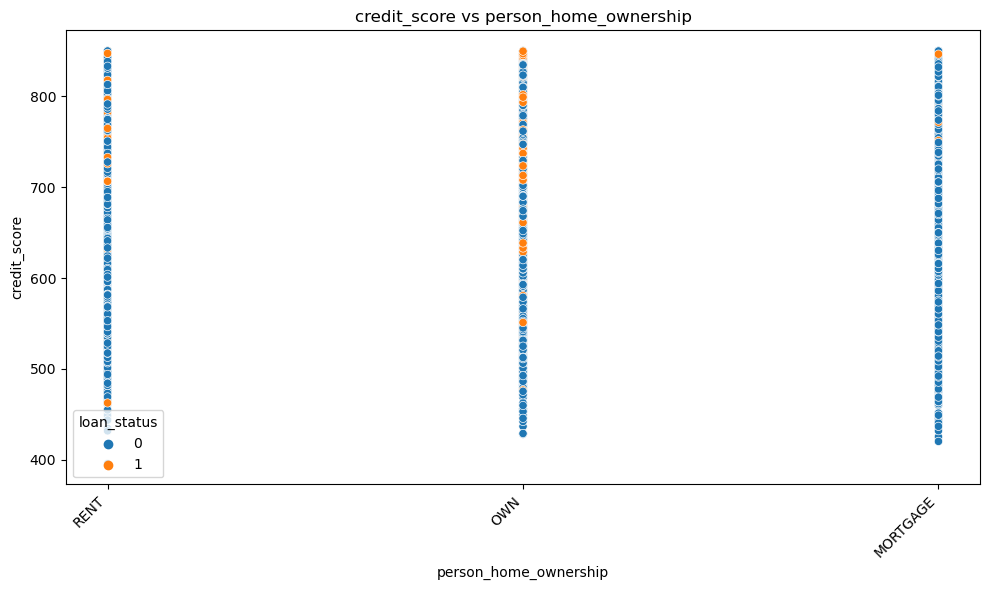

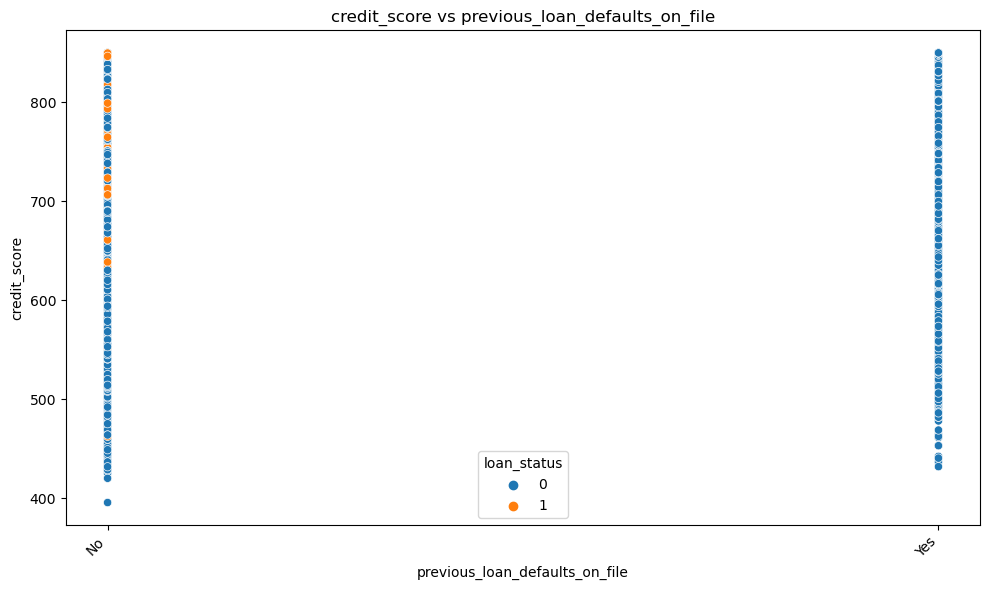

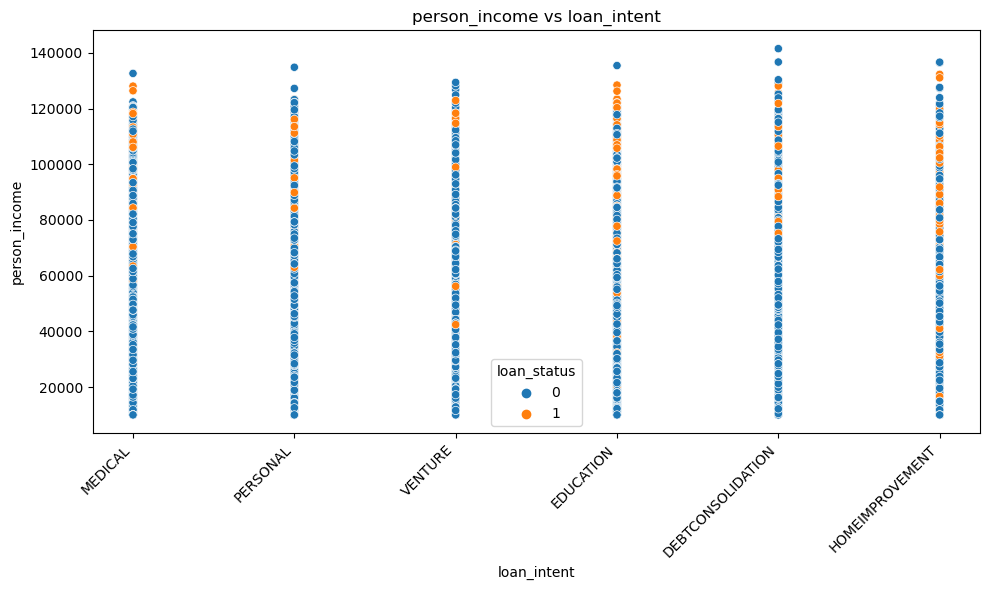

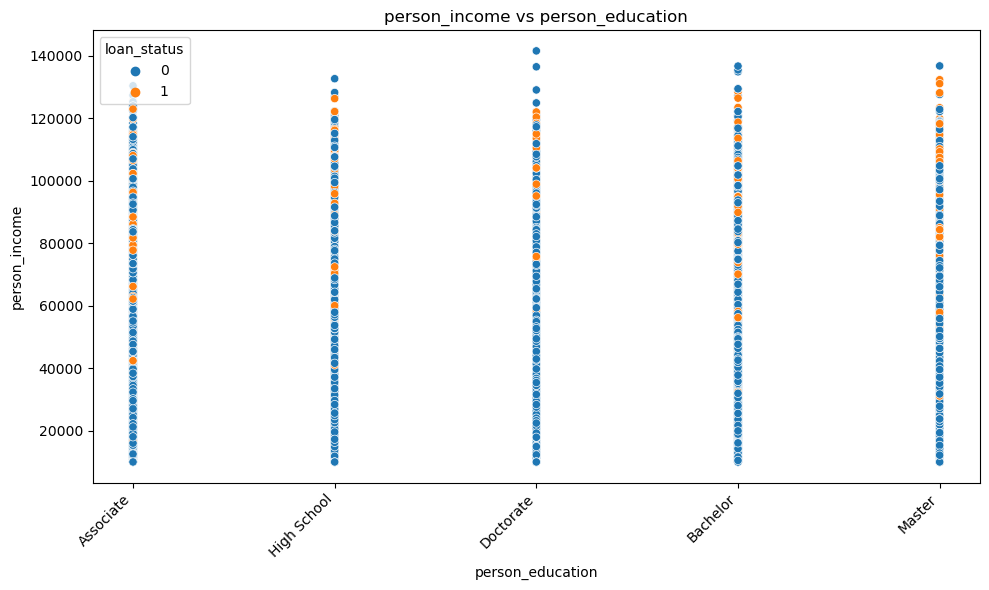

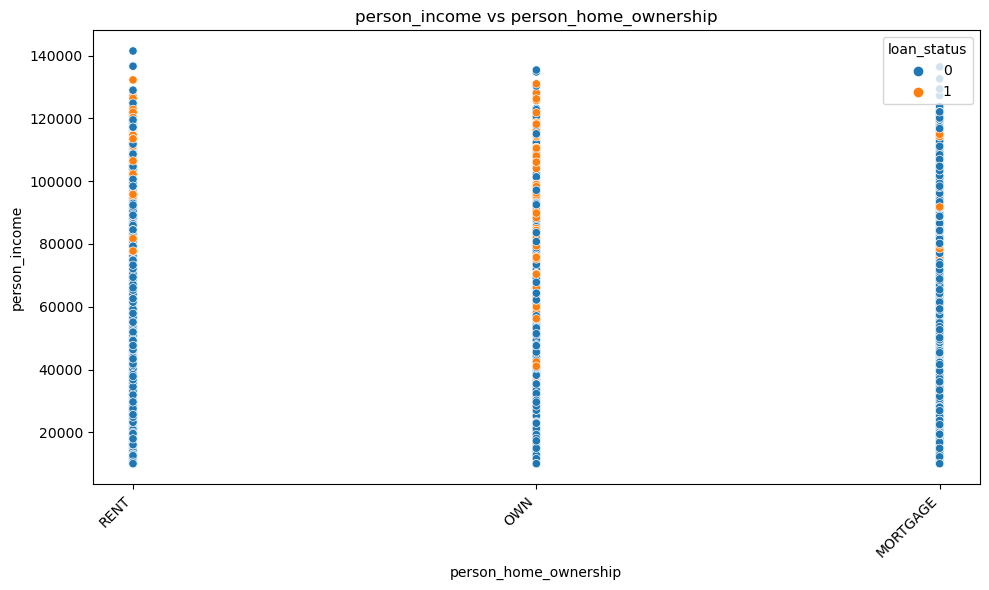

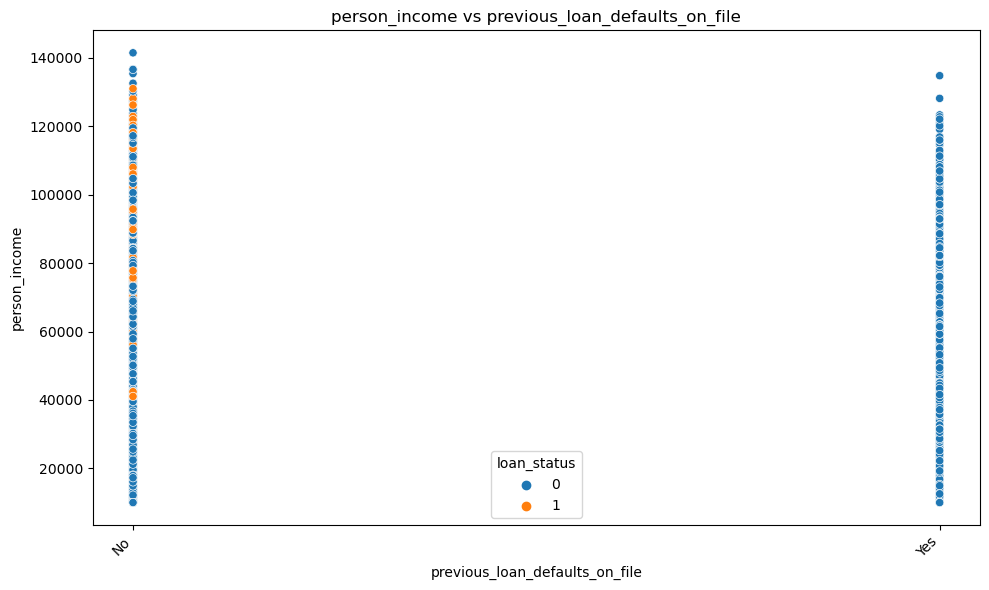

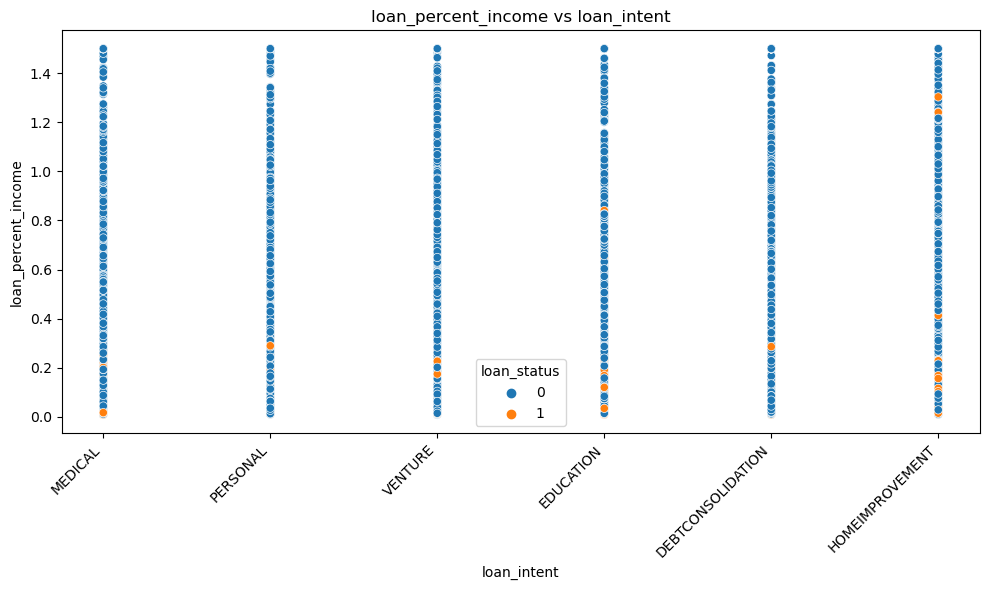

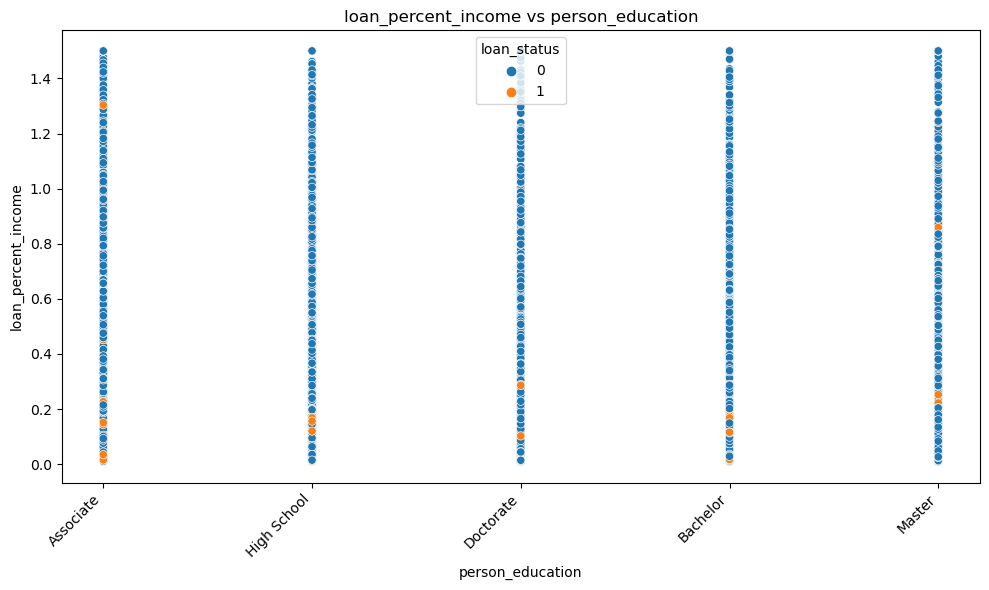

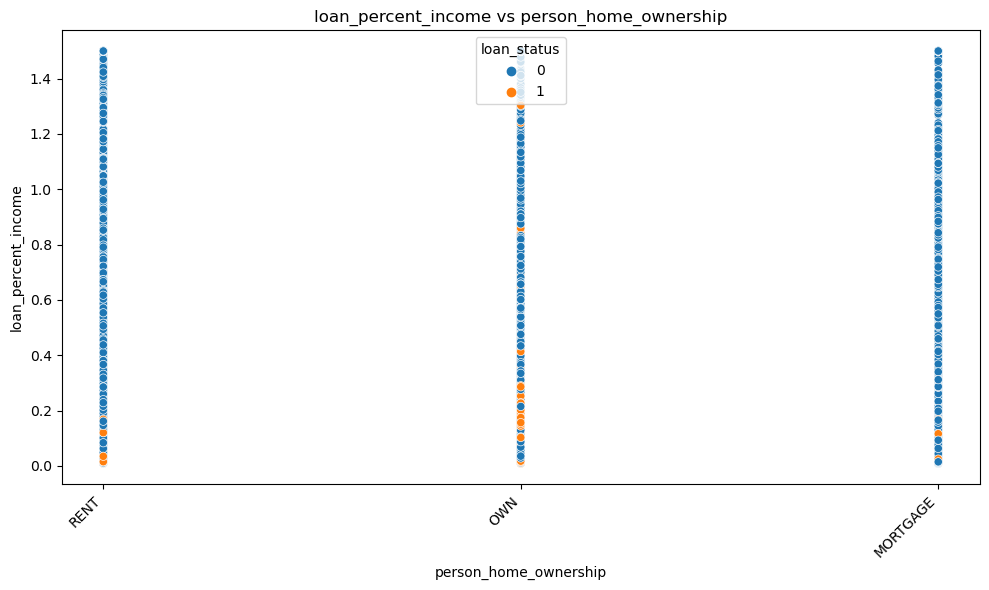

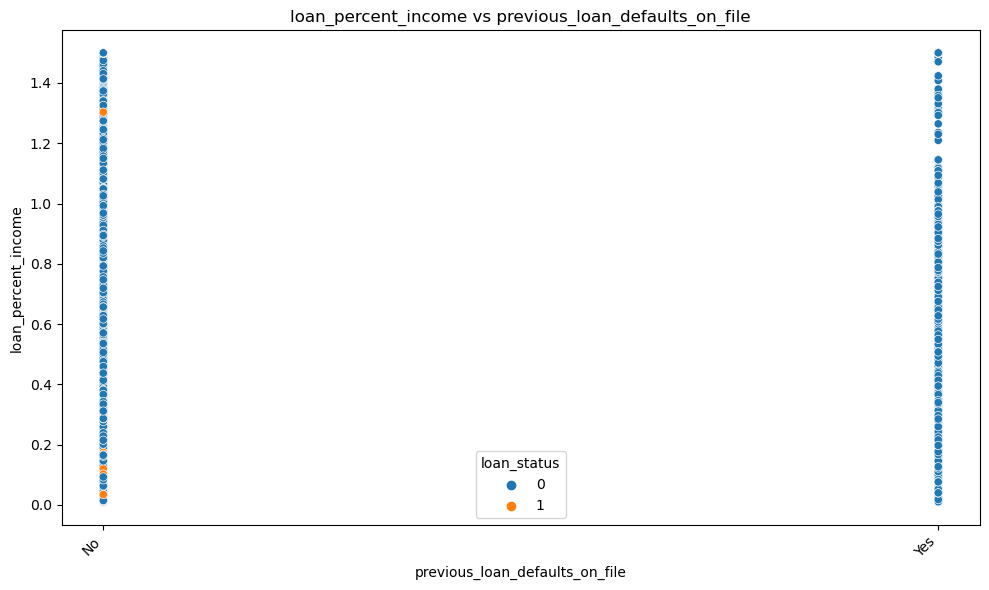

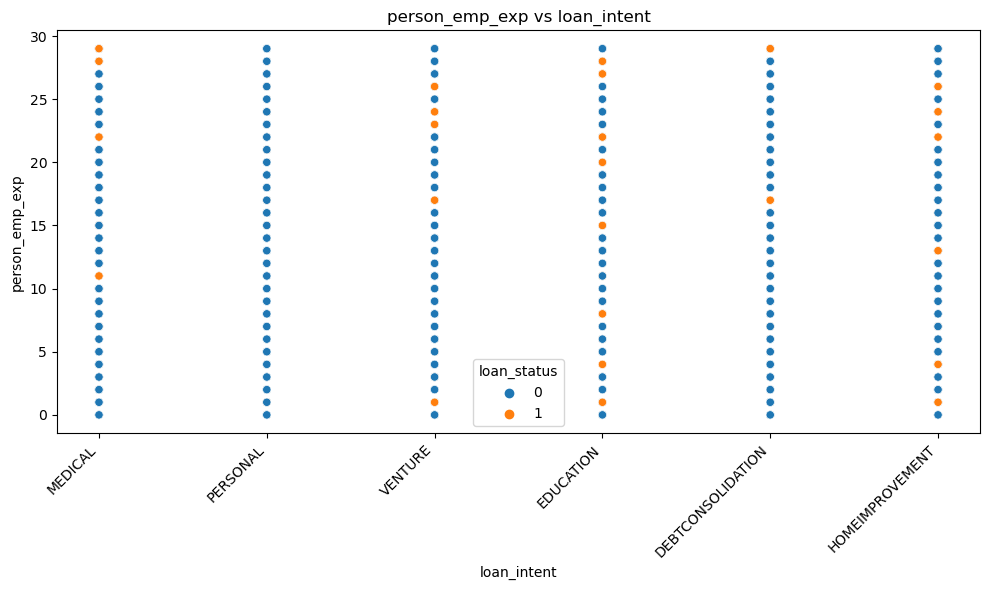

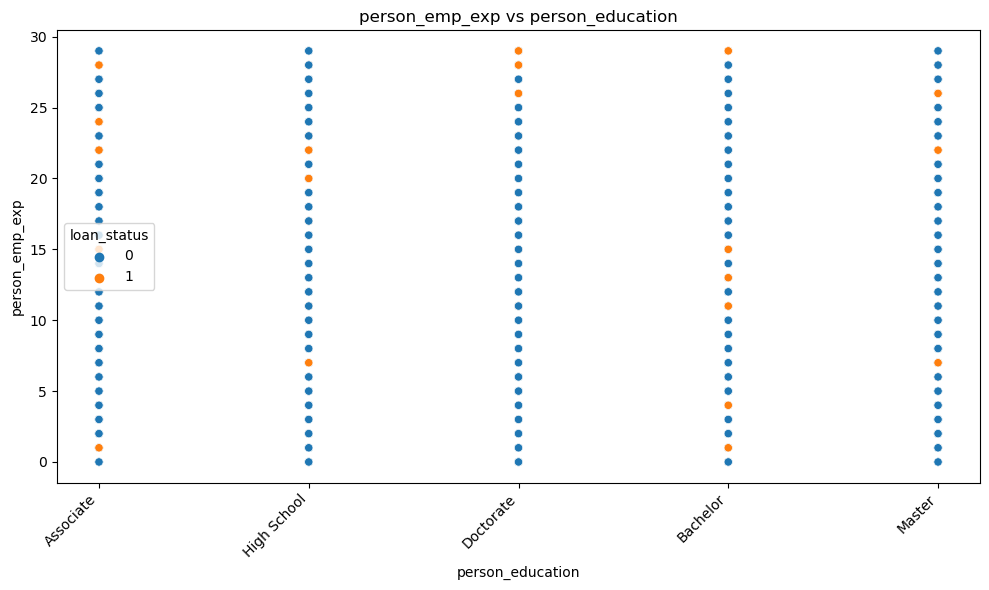

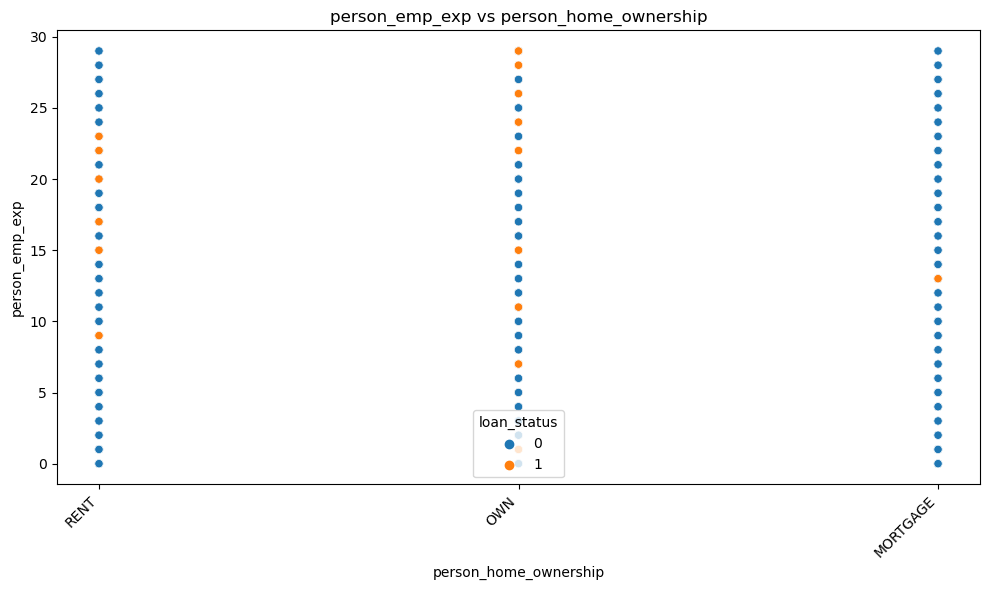

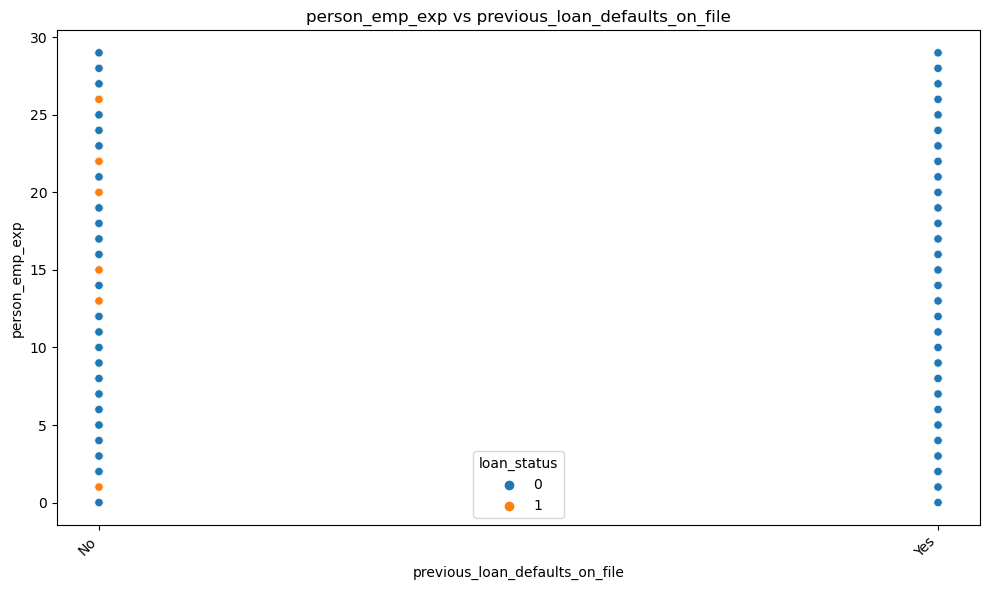

In [17]:
for feature in features:
    for factor in person_factors:
        plt.figure(figsize=(10,6))
        sns.scatterplot(
        data=df,
        x= factor,
        y = feature,
        hue = 'loan_status',
    )
        plt.xticks(rotation=45, ha='right')
        plt.title(f"{feature} vs {factor}")
        plt.tight_layout()
    plt.show()

In [ ]:
Some features that drive the decision is based on the loan amount,  
credit history length, credit score, and the age of the borrower.
The person's education is irrelevant to the decision.
Home Ownership could be a factor but it is not as strong as the other features.
Looks like there is no cause for legal concerns regarding the decision of the loan approval. 
Giving a clear view on how strict the loan approval process. 